In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('sales_2025.csv')

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['month'] = df['purchase_date'].dt.to_period('M').dt.to_timestamp()

In [2]:
# Метрики за 2025
sku = df['product_id'].nunique()
qty = df['quantity'].sum()
revenue = df['total_price'].sum()
avg_price = revenue / qty
clients = df['client_id'].nunique()
revenue_per_client = revenue / clients
orders_per_client = df.groupby('client_id')['quantity'].count().mean()
orders = df.groupby(['client_id', 'purchase_date']).agg(
    quantity=('quantity', 'sum'),
    total_price=('total_price', 'sum')
).reset_index()
avg_items_per_order = orders['quantity'].mean()
revenue_per_order = orders['total_price'].mean()
# Соотношение M / F (по уникальным клиентам)
gender_dist = df.groupby('client_id')['gender'].first().value_counts(normalize=True) * 100
m_pct = gender_dist.get('M', 0)
f_pct = gender_dist.get('F', 0)

print("=== Ключевые метрики за 2025 ===")
print(f"SKU: {sku:,}")
print(f"Продано штук: {qty:,.0f}")
print(f"Выручка: {revenue:,.0f} руб. ({revenue/1e6:.1f} млн руб.)")
print(f"Средняя цена товара: {avg_price:,.0f} руб.")
print(f"Уникальных клиентов: {clients:,}")
print(f"Выручка на клиента: {revenue_per_client:,.0f} руб.")
print(f"Среднее количество заказов на клиента: {orders_per_client:.2f}")
print(f"Среднее количество товаров в заказе (оценка): {avg_items_per_order:.2f} шт.")
print(f"Средняя выручка на заказ (оценка): {revenue_per_order:,.0f} руб.")
print(f"Соотношение M / F: {m_pct:.1f}% / {f_pct:.1f}%")

=== Ключевые метрики за 2025 ===
SKU: 50,000
Продано штук: 65,755,453
Выручка: 1,641,805,063,884 руб. (1641805.1 млн руб.)
Средняя цена товара: 24,968 руб.
Уникальных клиентов: 858,571
Выручка на клиента: 1,912,253 руб.
Среднее количество заказов на клиента: 2.28
Среднее количество товаров в заказе (оценка): 33.75 шт.
Средняя выручка на заказ (оценка): 842,734 руб.
Соотношение M / F: 50.0% / 50.0%


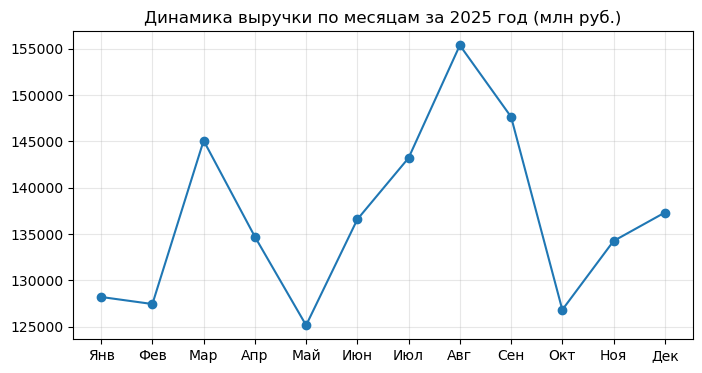

In [3]:
# Группировка продаж по месяцам за 2025
df_2025 = df[df['purchase_date'].dt.year == 2025].copy()
df_2025['month'] = df_2025['purchase_date'].dt.month
monthly = df_2025.groupby('month').agg(
    total_qty=('quantity', 'sum'),
    total_revenue=('total_price', 'sum')
).reindex(range(1, 13), fill_value=0)

# График выручки
plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly['total_revenue'] / 1e6, marker='o', color='#1f77b4')
plt.title('Динамика выручки по месяцам за 2025 год (млн руб.)')
plt.xticks(range(1, 13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.grid(True, alpha=0.3)
plt.show()

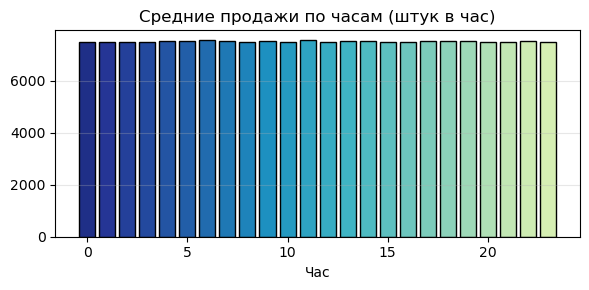

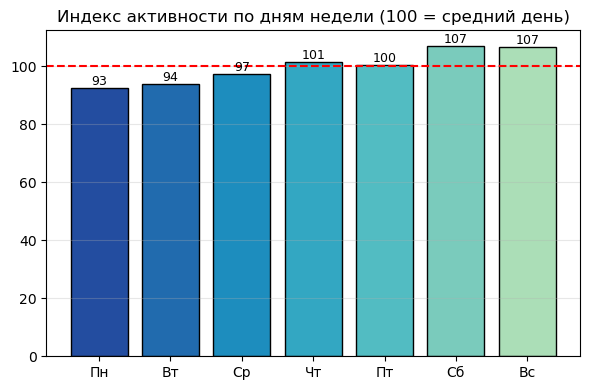

In [4]:
# Среднее количество штук за час (усреднённое по дням)
df['hour'] = (df['purchase_time_seconds'] // 3600) % 24

hourly = df.groupby(['purchase_date', 'hour'])['quantity'].sum().reset_index()
hourly_avg = hourly.groupby('hour')['quantity'].mean()

colors_hours = plt.cm.YlGnBu(np.linspace(0.9, 0.2, 24))

plt.figure(figsize=(6, 3))
plt.bar(hourly_avg.index, hourly_avg.values, color=colors_hours, edgecolor='black')
plt.title('Средние продажи по часам (штук в час)', fontsize=12)
plt.xlabel('Час')
plt.ylabel('')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df['weekday'] = df['purchase_date'].dt.weekday

daily = df.groupby(['purchase_date', 'weekday'])['quantity'].sum().reset_index()
weekday_avg = daily.groupby('weekday')['quantity'].mean().reindex(range(7), fill_value=0)

weekday_index = weekday_avg / weekday_avg.mean() * 100

# --- график ---
weekday_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
colors = plt.cm.YlGnBu(np.linspace(0.8, 0.3, 7))

plt.figure(figsize=(6, 4))
bars = plt.bar(weekday_labels, weekday_index.values, color=colors, edgecolor='black')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:.0f}', ha='center', va='bottom', fontsize=9)

plt.axhline(100, color='red', linestyle='--')
plt.title('Индекс активности по дням недели (100 = средний день)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Топ-10 товаров по выручке с процентом от общей выручки
total_revenue = df['total_price'].sum()

top10 = df.groupby('product_id')['total_price'].sum().sort_values(ascending=False).head(10).reset_index()
top10.columns = ['product_id', 'revenue']


print("=== Топ-10 товаров по выручке ===")
print(top10.to_string(index=False))


=== Топ-10 товаров по выручке ===
 product_id     revenue
      42926 120462804.0
      25088 117259045.0
      42455 112089344.0
      17169 111773812.0
      26759 111534709.0
      10084 110675882.0
      47930 110157616.0
      30133 109159060.0
       4527 108235490.0
      41713 108163952.0


=== Матрица ABC-XYZ (по выручке) ===
XYZ         X      Y     Z
ABC_rev                   
A        1715  18399  6928
B         613   7424  3460
C         576   7391  3494

Средний CV: 67.0
Медианный CV: 65.9

Доля выручки по категориям ABC-XYZ (%):
XYZ        X     Y     Z
ABC_rev                 
A        5.4  55.2  19.4
B        0.8   9.7   4.5
C        0.2   3.2   1.5


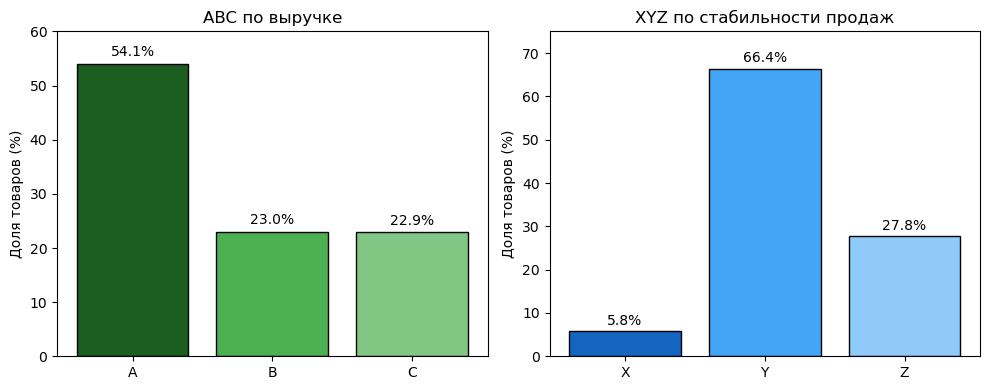

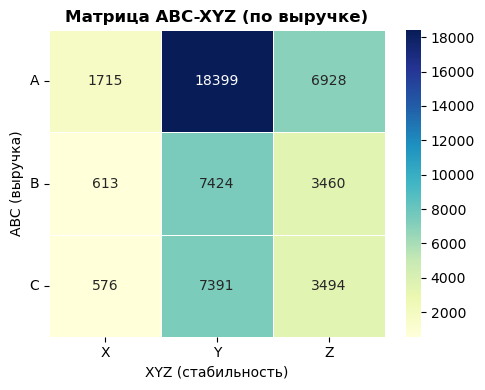

In [6]:
# 1. ABC по выручке
products = df.groupby('product_id').agg(
    revenue=('total_price', 'sum'),
    total_qty=('quantity', 'sum')
).reset_index()

df_abc_rev = products.sort_values('revenue', ascending=False).copy()
df_abc_rev['cumulative_share'] = df_abc_rev['revenue'].cumsum() / df_abc_rev['revenue'].sum()
df_abc_rev['ABC_rev'] = pd.cut(
    df_abc_rev['cumulative_share'],
    bins=[0, 0.8, 0.95, 1.0],
    labels=['A', 'B', 'C'],
    right=True,
    include_lowest=True
)

# 2. XYZ по количеству (мягкие границы)
xyz_base = df.groupby(['product_id', 'month']).agg(
    qty=('quantity', 'sum')
).reset_index()

all_months = sorted(xyz_base['month'].unique())
products_list = pd.DataFrame({'product_id': df['product_id'].unique()})

full = products_list.assign(key=1).merge(
    pd.DataFrame({'month': all_months, 'key': 1}), on='key'
).drop('key', axis=1)

xyz_full = full.merge(xyz_base, on=['product_id', 'month'], how='left')
xyz_full['qty'] = xyz_full['qty'].fillna(0)

xyz_stats = xyz_full.groupby('product_id').agg(
    mean_qty=('qty', 'mean'),
    std_qty=('qty', 'std'),
    total_qty=('qty', 'sum')
).reset_index()

xyz_stats['cv'] = (xyz_stats['std_qty'] / xyz_stats['mean_qty'].replace(0, np.nan)) * 100
xyz_stats['cv'] = xyz_stats['cv'].fillna(100)

def xyz_category(cv):
    if cv <= 45:
        return 'X'
    elif cv <= 75:
        return 'Y'
    else:
        return 'Z'

xyz_stats['XYZ'] = xyz_stats['cv'].apply(xyz_category)

# 3. Объединяем с revenue
combined = xyz_stats.merge(
    df_abc_rev[['product_id', 'ABC_rev', 'revenue']],
    on='product_id'
)

# 4. Матрица
matrix = pd.crosstab(combined['ABC_rev'], combined['XYZ'], margins=False)
matrix = matrix.reindex(index=['A', 'B', 'C'], columns=['X', 'Y', 'Z'], fill_value=0)

print("=== Матрица ABC-XYZ (по выручке) ===")
print(matrix)
print("\nСредний CV:", round(xyz_stats['cv'].mean(), 1))
print("Медианный CV:", round(xyz_stats['cv'].median(), 1))

# 5. Доля выручки по категориям
category_revenue = combined.groupby(['ABC_rev', 'XYZ'], observed=False)['revenue'].sum().unstack(fill_value=0)
category_revenue_pct = category_revenue / category_revenue.sum().sum() * 100

print("\nДоля выручки по категориям ABC-XYZ (%):")
print(category_revenue_pct.round(1))

# 6. Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# ABC
abc_pct = combined['ABC_rev'].value_counts().sort_index() / len(combined) * 100
colors_abc = ['#1b5e20', '#4caf50', '#81c784']
bars1 = ax1.bar(abc_pct.index, abc_pct.values, color=colors_abc, edgecolor='black')
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}%', ha='center', va='bottom')
ax1.set_title('ABC по выручке')
ax1.set_ylabel('Доля товаров (%)')
ax1.set_ylim(0, 60)

# XYZ
xyz_pct = combined['XYZ'].value_counts().sort_index() / len(combined) * 100
colors_xyz = ['#1565c0', '#42a5f5', '#90caf9']
bars2 = ax2.bar(xyz_pct.index, xyz_pct.values, color=colors_xyz, edgecolor='black')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}%', ha='center', va='bottom')
ax2.set_title('XYZ по стабильности продаж')
ax2.set_ylabel('Доля товаров (%)')
ax2.set_ylim(0, 75)

plt.tight_layout()
plt.show()

# Матрица
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, cbar=True)
plt.title('Матрица ABC-XYZ (по выручке)', fontsize=12, fontweight='bold')
plt.ylabel('ABC (выручка)')
plt.xlabel('XYZ (стабильность)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== Доля продаж (штуки) по сегментам ===
price_segment
Budget      20.2
Standard    30.6
Premium     30.2
High-End    18.9
Luxury       0.1
Name: quantity, dtype: float64

=== Доля выручки по сегментам ===
price_segment
Budget       4.0
Standard    21.5
Premium     39.3
High-End    34.9
Luxury       0.3
Name: total_price, dtype: float64
=== Абсолютные показатели по сегментам (выручка в млн руб.) ===
               SKU (шт.)  Продажи (шт.)  Выручка (млн руб.)
price_segment                                              
Budget             10078       13254897             66074.4
Standard           15345       20113574            352207.1
Premium            15088       19875751            645043.6
High-End            9421       12424676            573100.1
Luxury                68          86555              5379.9


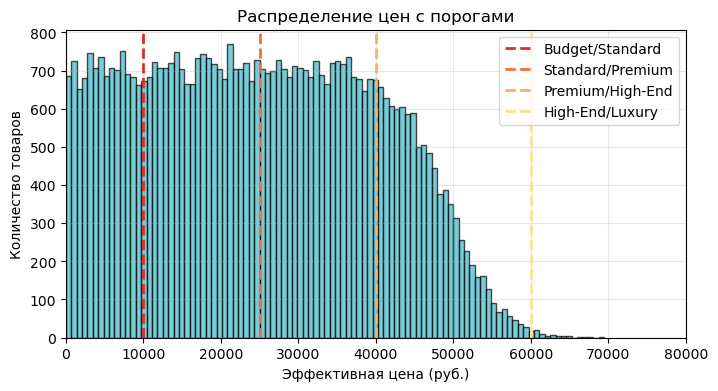

In [7]:
# 1. Расчёт эффективной цены и сегментов 
price_segments = df.groupby('product_id').agg(
    total_revenue=('total_price', 'sum'),
    total_qty=('quantity', 'sum')
).reset_index()
price_segments['effective_price'] = price_segments['total_revenue'] / price_segments['total_qty']

def get_price_segment(price):
    if price <= 10000:
        return 'Budget'
    elif price <= 25000:
        return 'Standard'
    elif price <= 40000:
        return 'Premium'
    elif price <= 60000:
        return 'High-End'
    else:
        return 'Luxury'

price_segments['price_segment'] = price_segments['effective_price'].apply(get_price_segment)

# 2. Присоединяем сегменты к исходным данным
df_with_segments = df.merge(
    price_segments[['product_id', 'price_segment']],
    on='product_id',
    how='left'
)

# 3. Доли в штуках и выручке
qty_by_segment = df_with_segments.groupby('price_segment')['quantity'].sum()
qty_share = qty_by_segment / qty_by_segment.sum() * 100

revenue_by_segment = df_with_segments.groupby('price_segment')['total_price'].sum()
revenue_share = revenue_by_segment / revenue_by_segment.sum() * 100

order = ['Budget', 'Standard', 'Premium', 'High-End', 'Luxury']
qty_share = qty_share.reindex(order).fillna(0)
revenue_share = revenue_share.reindex(order).fillna(0)

print("=== Доля продаж (штуки) по сегментам ===")
print(qty_share.round(1))
print("\n=== Доля выручки по сегментам ===")
print(revenue_share.round(1))

# Абсолютные показатели по сегментам
sku_abs = df_with_segments.groupby('price_segment')['product_id'].nunique().reindex(order).fillna(0)

# Продажи (штуки) и выручка — из df_with_segments
qty_abs = df_with_segments.groupby('price_segment')['quantity'].sum().reindex(order).fillna(0)
revenue_abs = df_with_segments.groupby('price_segment')['total_price'].sum().reindex(order).fillna(0)

# Абсолютные показатели по сегментам (выручка в миллионах)
summary_abs = pd.DataFrame({
    'SKU (шт.)': sku_abs,
    'Продажи (шт.)': qty_abs,
    'Выручка (млн руб.)': (revenue_abs / 1_000_000).round(1)
})

print("=== Абсолютные показатели по сегментам (выручка в млн руб.) ===")
print(summary_abs)

# 4. Гистограмма с порогами
plt.figure(figsize=(8, 4))
plt.hist(price_segments['effective_price'], bins=100, edgecolor='black', alpha=0.7, color= '#41b6c4')

thresholds = [10000, 25000, 40000, 60000]
colors_vert = ['#d73027', '#f46d43', '#fdae61', '#fee090']
labels_vert = ['Budget/Standard', 'Standard/Premium', 'Premium/High-End', 'High-End/Luxury']

for t, c, l in zip(thresholds, colors_vert, labels_vert):
    plt.axvline(x=t, color=c, linestyle='--', linewidth=2, label=l)

plt.title('Распределение цен с порогами')
plt.xlabel('Эффективная цена (руб.)')
plt.ylabel('Количество товаров')
plt.legend()
plt.xlim(0, 80000)
plt.grid(True, alpha=0.3)
plt.show()



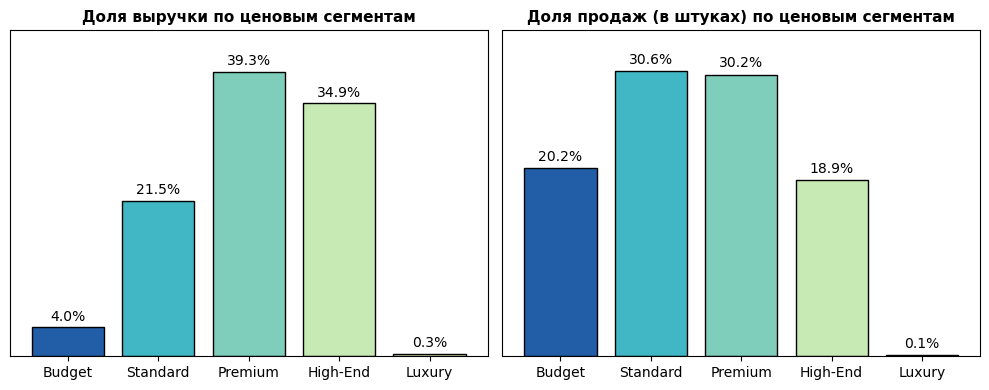

In [8]:
segments = ['Budget', 'Standard', 'Premium', 'High‑End', 'Luxury']
revenue_share = [4.0, 21.5, 39.3, 34.9, 0.3]
qty_share = [20.2, 30.6, 30.2, 18.9, 0.1]

colors_ylgnbu = ['#225ea8', '#41b6c4', '#7fcdbb', '#c7e9b4', '#ffffcc']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Выручка
bars1 = ax1.bar(segments, revenue_share, color=colors_ylgnbu, edgecolor='black')
ax1.set_title('Доля выручки по ценовым сегментам', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 45)
ax1.yaxis.set_visible(False)  

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Продажи
bars2 = ax2.bar(segments, qty_share, color=colors_ylgnbu, edgecolor='black')
ax2.set_title('Доля продаж (в штуках) по ценовым сегментам', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 35)
ax2.yaxis.set_visible(False)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
# RFM

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
last_date = df['purchase_date'].max()

rfm_df = df.groupby('client_id').agg(
    recency=('purchase_date', lambda x: (last_date - x.max()).days),
    frequency=('purchase_date', 'count'),       
    monetary=('total_price', 'sum'),
    total_orders=('purchase_date', 'count')  
).reset_index()


# Пороги (гибридный подход)

# Recency (чем меньше — тем лучше)
r_bins = [0, 30, 60, 90, 180, float('inf')]
rfm_df['R'] = pd.cut(rfm_df['recency'], bins=r_bins, labels=[5,4,3,2,1], right=False)

# Frequency
f_bins = [1, 2, 3, 4, 5, float('inf')]
rfm_df['F'] = pd.cut(rfm_df['frequency'], bins=f_bins, labels=[1,2,3,4,5], right=False)

# Monetary
rfm_df['M'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5])


rfm_df[['R', 'F', 'M']] = rfm_df[['R', 'F', 'M']].astype(int)


# RFM Score и сегменты

rfm_df['RFM_Score'] = rfm_df['R'] + rfm_df['F'] + rfm_df['M']
def rfm_segment(row):
    r = row['R']
    f = row['F']
    m = row['M']
    
    # === ТОП ===
    if r >= 4 and f >= 4 and m == 5:
        return 'Champions'
    
    elif r >= 4 and f >= 3 and m >= 4:
        return 'Loyal High-Value'
    
    elif r >= 4 and f >= 3:
        return 'Loyal'
    
    elif m >= 4 and r >= 3:
        return 'High Value'
    
    # === СВЕЖИЕ КЛИЕНТЫ ===
    elif r >= 4:
        return 'Recent Buyers'
        
    # === РИСК / СПЯЩИЕ ===
    elif r == 3 and f >= 2:
        return 'At Risk'
        
    elif r == 2 and f >= 2:
        return 'Sleeping'      
    
    # === ОДИН РАЗ И ДАВНО ===
    elif f == 1:
        return 'One Time Buyer'
    
    # === ПОТЕРЯННЫЕ (купили больше 1 раза и давно) ===
    else:
        return 'Lost'
        
rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)


# Результаты

print("=== RFM Анализ ===")
print(f"Всего клиентов: {len(rfm_df):,}")

print("\nРаспределение по сегментам:")
seg = rfm_df['Segment'].value_counts()
print(seg)
print("\nДоля сегментов (%):")
print((seg / len(rfm_df) * 100).round(2))

print("\nСредние показатели по сегментам:")
print(rfm_df.groupby('Segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'RFM_Score': 'mean'
}).round(2))


=== RFM Анализ ===
Всего клиентов: 858,571

Распределение по сегментам:
Segment
One Time Buyer      229482
Sleeping            183081
Lost                 94774
Recent Buyers        89229
High Value           80616
Loyal High-Value     60517
Loyal                45851
Champions            38923
At Risk              36098
Name: count, dtype: int64

Доля сегментов (%):
Segment
One Time Buyer      26.73
Sleeping            21.32
Lost                11.04
Recent Buyers       10.39
High Value           9.39
Loyal High-Value     7.05
Loyal                5.34
Champions            4.53
At Risk              4.20
Name: count, dtype: float64

Средние показатели по сегментам:
                  recency  frequency    monetary  RFM_Score
Segment                                                    
At Risk             73.14       2.56   886867.25       7.87
Champions           25.39       4.78  5591838.94      14.09
High Value          53.45       2.59  3574319.86      10.68
Lost               235.84 

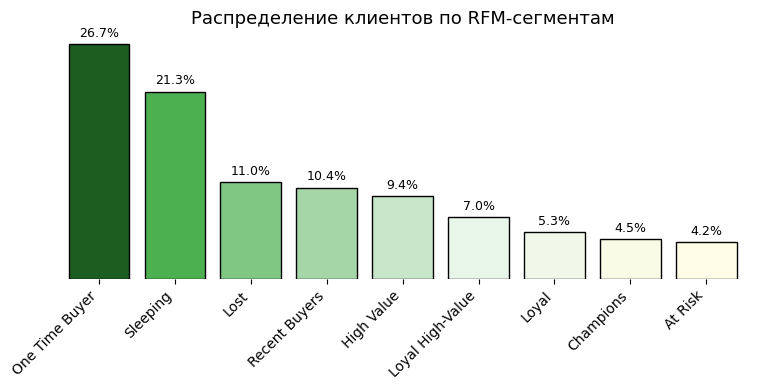

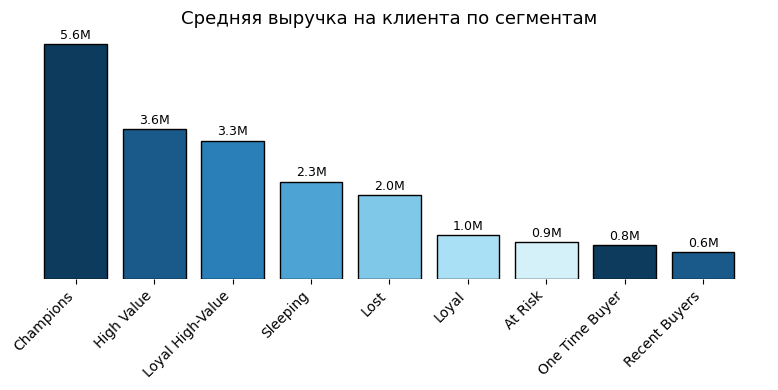

In [10]:
# Распределение клиентов по сегментам (доли, %)

seg_pct = rfm_df['Segment'].value_counts(normalize=True) * 100
seg_pct = seg_pct.sort_values(ascending=False)

colors_seg = ['#1b5e20', '#4caf50', '#81c784', '#a5d6a7', '#c8e6c9', '#e8f5e9', '#f1f8e9', '#f9fbe7', '#fffde7']

plt.figure(figsize=(8, 4))
bars = plt.bar(seg_pct.index, seg_pct.values, color=colors_seg[:len(seg_pct)], edgecolor='black')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Распределение клиентов по RFM-сегментам', fontsize=13)
plt.ylabel('Доля клиентов (%)')
plt.xticks(rotation=45, ha='right')
plt.gca().axes.get_yaxis().set_visible(False)   
plt.box(False)  
plt.tight_layout()
plt.show()

# Выручка по сегментам (млн руб.)

revenue_by_segment = rfm_df.groupby('Segment')['monetary'].mean().sort_values(ascending=False) / 1_000_000

colors_blue = ['#0d3b5e', '#1a5a8a', '#2a7fb8', '#4ca3d4', '#7fc8e8', '#aae0f5', '#d4f1f9']

plt.figure(figsize=(8, 4))
bars = plt.bar(revenue_by_segment.index, revenue_by_segment.values, color=colors_blue, edgecolor='black')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.1f}M', ha='center', va='bottom', fontsize=9)

plt.title('Средняя выручка на клиента по сегментам', fontsize=13)
plt.ylabel('Выручка (млн руб.)')
plt.xticks(rotation=45, ha='right')
plt.gca().axes.get_yaxis().set_visible(False) 
plt.box(False) 
plt.tight_layout()
plt.show()

Новые клиенты 2025 года          : 17,016
Реактивированные клиенты       : 414,747
СРАВНЕНИЕ ГРУПП
ARPU Новые клиенты          : 1,905,169 руб.
ARPU Реактивированные       : 1,686,729 руб.
AOV Новые клиенты           : 837,814 руб.
AOV Реактивированные        : 837,936 руб.


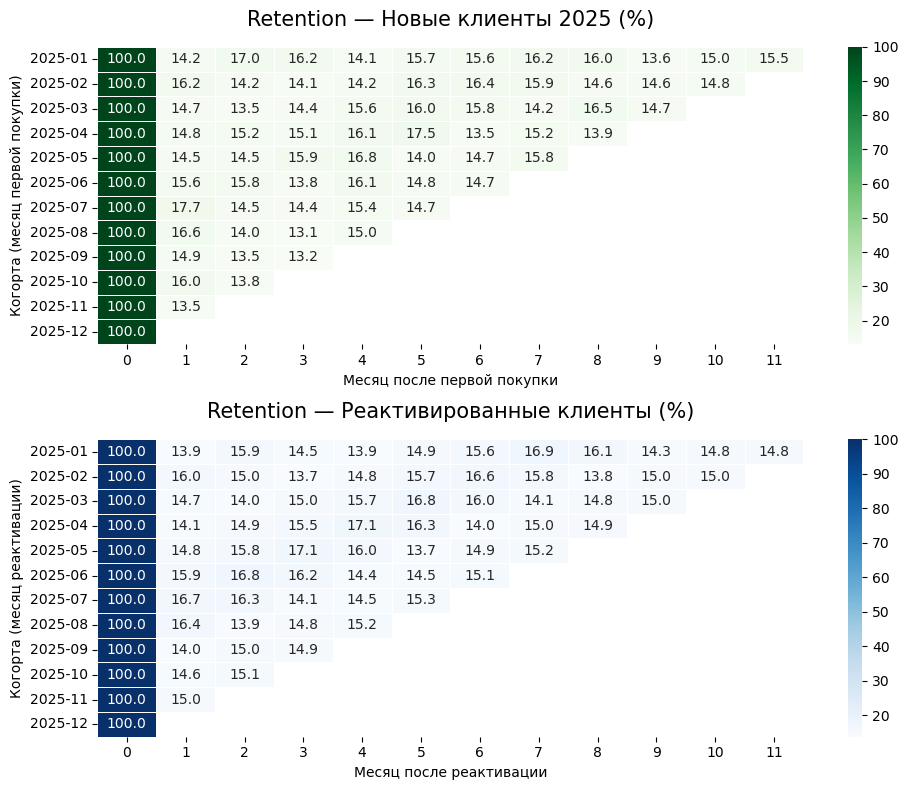

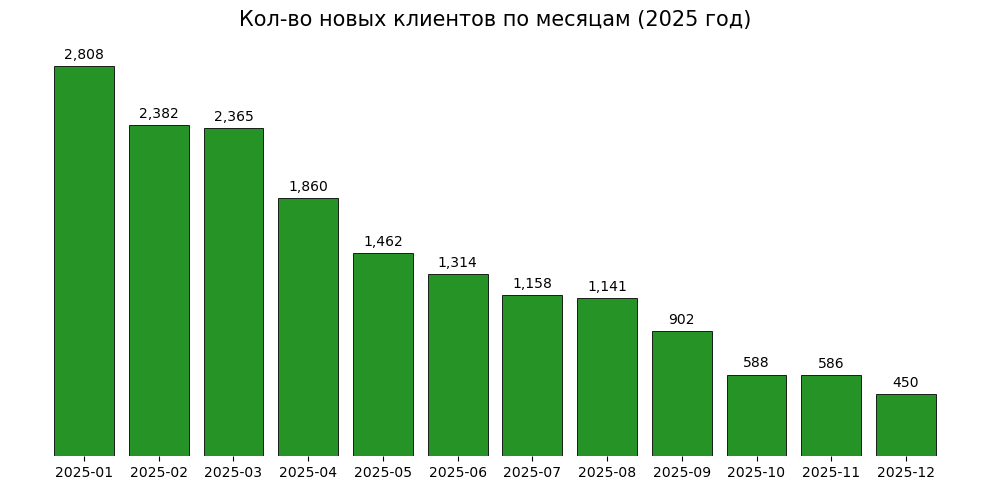

In [53]:

clients = pd.read_csv('clients.csv', parse_dates=['first_purchase_ever', 
                                                  'last_purchase_pre_2025', 
                                                  'first_purchase_2025'])
# Новые клиенты 2025

new_clients = clients[clients['first_purchase_ever'].dt.year == 2025]['client_id'].unique()

df_new = df[df['client_id'].isin(new_clients)].copy()
df_new = df_new.merge(
    clients[['client_id', 'first_purchase_ever']], 
    on='client_id'
)
df_new['cohort'] = df_new['first_purchase_ever'].dt.to_period('M')

# Реактивированные клиенты (перерыв ≥ 270 дней)

react_mask = (
    clients['last_purchase_pre_2025'].notna() &
    clients['first_purchase_2025'].notna() &
    ((clients['first_purchase_2025'] - clients['last_purchase_pre_2025']).dt.days >= 270)
)

react_clients = clients[react_mask]['client_id'].unique()

df_react = df[df['client_id'].isin(react_clients)].copy()
df_react = df_react.merge(
    clients[['client_id', 'first_purchase_2025']], 
    on='client_id'
)

df_react = df_react[df_react['purchase_date'] >= df_react['first_purchase_2025']].copy()
df_react['cohort'] = df_react['first_purchase_2025'].dt.to_period('M')

print(f"Новые клиенты 2025 года          : {len(df_new['client_id'].unique()):,}")
print(f"Реактивированные клиенты       : {len(df_react['client_id'].unique()):,}")


# Численность когорт

cohort_size_new = df_new.groupby('cohort')['client_id'].nunique().sort_index()
cohort_size_react = df_react.groupby('cohort')['client_id'].nunique().sort_index()

# Ключевые метрики

print("СРАВНЕНИЕ ГРУПП")
print(f"ARPU Новые клиенты          : {df_new.groupby('client_id')['total_price'].sum().mean():,.0f} руб.")
print(f"ARPU Реактивированные       : {df_react.groupby('client_id')['total_price'].sum().mean():,.0f} руб.")
print(f"AOV Новые клиенты           : {df_new['total_price'].mean():,.0f} руб.")
print(f"AOV Реактивированные        : {df_react['total_price'].mean():,.0f} руб.")

# Функция для Retention

def retention_table(df):
    df = df.copy()
    df['order_month'] = df['purchase_date'].dt.to_period('M')
    df['month_number'] = (df['order_month'] - df['cohort']).apply(lambda x: x.n)
    
    ret = df.groupby(['cohort', 'month_number'])['client_id'].nunique().reset_index()
    pivot = ret.pivot(index='cohort', columns='month_number', values='client_id')
    
    # Retention в процентах
    retention = pivot.divide(pivot.iloc[:, 0], axis=0) * 100
    return retention.round(1)

ret_new = retention_table(df_new)
ret_react = retention_table(df_react)

# Визуализации

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Новые клиенты 
sns.heatmap(ret_new, 
            annot=True, 
            fmt='.1f', 
            cmap='Greens', 
            linewidths=0.6, 
            linecolor='white',
            ax=axes[0])
axes[0].set_title('Retention — Новые клиенты 2025 (%)', fontsize=15, pad=15)
axes[0].set_xlabel('Месяц после первой покупки')
axes[0].set_ylabel('Когорта (месяц первой покупки)')

# Реактивированные
sns.heatmap(ret_react, 
            annot=True, 
            fmt='.1f', 
            cmap='Blues', 
            linewidths=0.6, 
            linecolor='white',
            ax=axes[1])
axes[1].set_title('Retention — Реактивированные клиенты (%)', fontsize=15, pad=15)
axes[1].set_xlabel('Месяц после реактивации')
axes[1].set_ylabel('Когорта (месяц реактивации)')

plt.tight_layout()
plt.show()

# Размер когорт новых клиентов

plt.figure(figsize=(10, 5))

# Основной график
bars = plt.bar(cohort_size_new.index.astype(str), cohort_size_new.values, 
               color='Green', alpha=0.85, edgecolor='black', linewidth=0.7)

plt.title('Кол-во новых клиентов по месяцам (2025 год)', 
          fontsize=15, pad=15)
plt.ylabel('Количество клиентов в когорте', fontsize=12)
# Убираем ось Y
plt.gca().axes.get_yaxis().set_visible(False)
plt.box(False)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 30, 
             f'{int(height):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.show()

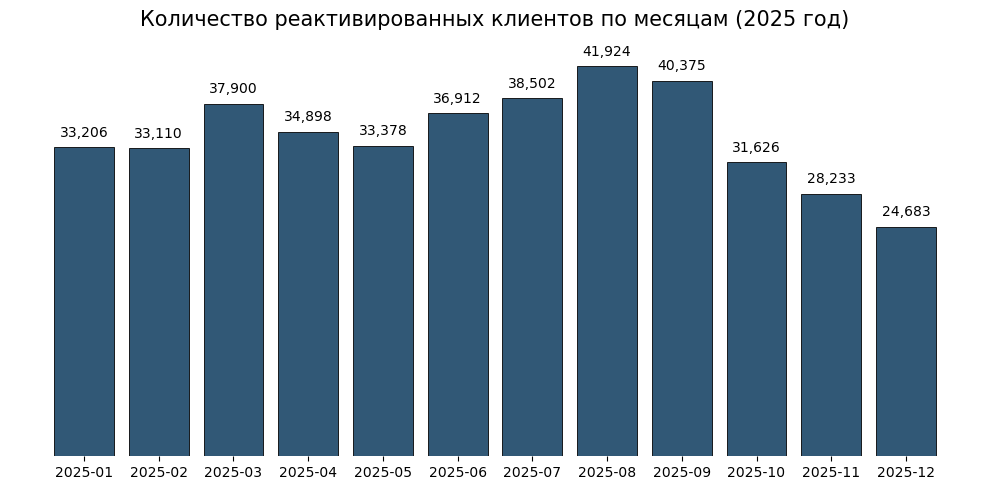

In [57]:
# Размер когорт реактивированных клиентов

plt.figure(figsize=(10, 5))

# Основной график
bars = plt.bar(cohort_size_react.index.astype(str), cohort_size_react.values, 
               color='#0d3b5e', alpha=0.85, edgecolor='black', linewidth=0.7)

plt.title('Количество реактивированных клиентов по месяцам (2025 год)', 
          fontsize=15, pad=15)
plt.ylabel('Количество клиентов в когорте', fontsize=12)

# Убираем ось Y и рамку
plt.gca().axes.get_yaxis().set_visible(False)
plt.box(False)

# Подписи значений
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 800, 
             f'{int(height):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.show()


=== Среднее удержание по месяцам (%) ===
              New 2025  Reactivated
month_number                       
0                100.0        100.0
1                 15.3         15.1
2                 14.6         15.3
3                 14.5         15.1
4                 15.4         15.2
5                 15.6         15.3
6                 15.1         15.4
7                 15.5         15.4
8                 15.2         14.9
9                 14.3         14.8
10                14.9         14.9
11                15.5         14.8


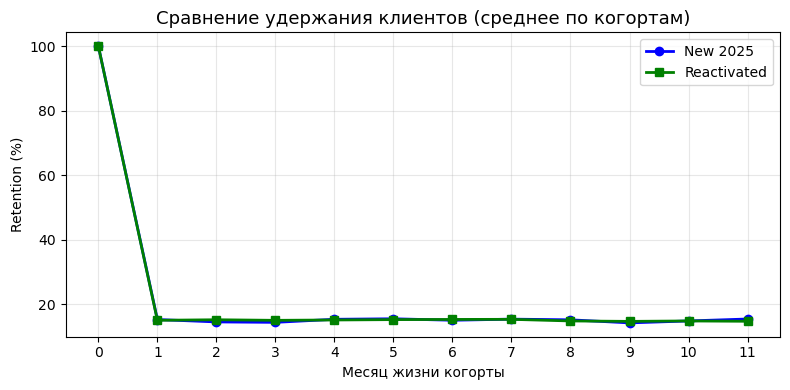


=== LTV (накопленная выручка на клиента) ===
LTV New 2025 (за 6 месяцев)  : 1,402,828 руб.
LTV Reactivated (за 6 месяцев): 1,424,677 руб.
LTV New 2025 (за 12 месяцев) : 1,645,681 руб.
LTV Reactivated (за 12 месяцев): 1,665,595 руб.


In [38]:
# ======================
# 6. Среднее удержание по группам
# ======================
ret_new_mean = ret_new.mean(axis=0).rename('New 2025')
ret_react_mean = ret_react.mean(axis=0).rename('Reactivated')

ret_comparison = pd.DataFrame({
    'New 2025': ret_new_mean,
    'Reactivated': ret_react_mean
})

# ======================
# 7. График удержания
# ======================
plt.figure(figsize=(8, 4))
plt.plot(ret_comparison.index, ret_comparison['New 2025'], 
         marker='o', linewidth=2, label='New 2025', color = 'Blue')
plt.plot(ret_comparison.index, ret_comparison['Reactivated'], 
         marker='s', linewidth=2, label='Reactivated', color='Green')

plt.title('Сравнение удержания клиентов (среднее по когортам)', fontsize=13)
plt.xlabel('Месяц жизни когорты')
plt.ylabel('Retention (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, len(ret_comparison)))
plt.tight_layout()
plt.show()

# ======================
# 8. LTV (накопленная выручка на клиента)
# ======================
def cumulative_revenue_per_user(df):
    df = df.copy()
    df['order_month'] = df['purchase_date'].dt.to_period('M')
    df['month_number'] = (df['order_month'] - df['cohort']).apply(lambda x: x.n)
    
    # Суммарная выручка по когорте и месяцу
    revenue = df.groupby(['cohort', 'month_number'])['total_price'].sum().reset_index()
    rev_pivot = revenue.pivot(index='cohort', columns='month_number', values='total_price').fillna(0)
    
    # Накопленная выручка
    rev_cumsum = rev_pivot.cumsum(axis=1)
    
    # Количество клиентов в когорте
    n_clients = df.groupby('cohort')['client_id'].nunique()
    
    # LTV в рублях
    ltv = rev_cumsum.divide(n_clients, axis=0)
    return ltv

ltv_new = cumulative_revenue_per_user(df_new)
ltv_react = cumulative_revenue_per_user(df_react)

# ======================
# 9. Вывод LTV
# ======================
print("\n=== LTV (накопленная выручка на клиента) ===")
print(f"LTV New 2025 (за 6 месяцев)  : {ltv_new.iloc[:, :6].iloc[:, -1].dropna().mean():,.0f} руб.")
print(f"LTV Reactivated (за 6 месяцев): {ltv_react.iloc[:, :6].iloc[:, -1].dropna().mean():,.0f} руб.")

if ltv_new.shape[1] >= 12:
    print(f"LTV New 2025 (за 12 месяцев) : {ltv_new.iloc[:, 11].mean():,.0f} руб.")
if ltv_react.shape[1] >= 12:
    print(f"LTV Reactivated (за 12 месяцев): {ltv_react.iloc[:, 11].mean():,.0f} руб.")
